In [8]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18w/WC06.txt")

In [10]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

12
1000
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[[41, 7, 1, 2, 2, 6, 3, 2, 4, 2, 7, 3, 2], [39, 1, 2, 1, 5, 0, 6, 6, 1, 3, 2, 0, 3], [20, 3, 3, 2, 4, 6, 3, 3, 2, 7, 3, 10, 1], [61, 2, 5, 4, 5, 3, 3, 2, 5, 3, 4, 4, 1], [18, 2, 5, 4, 2, 0, 4, 1, 2, 1, 3, 5, 1], [23, 2, 2, 2, 4, 2, 4, 5, 3, 7, 3, 5, 5], [25, 2, 2, 6, 5, 7, 1, 5, 3, 3, 6, 3, 4], [13, 5, 6, 2, 3, 4, 5, 1, 6, 3, 5, 4, 3], [77, 4, 3, 5, 4, 1, 2, 7, 1, 3, 3, 4, 3], [8, 6, 5, 4, 2, 1, 3, 1, 4, 3, 1, 8, 3], [25, 4, 2, 5, 2, 1, 1, 2, 1, 9, 4, 2, 2], [74, 5, 4, 4, 2, 5, 4, 0, 2, 2, 1, 6, 5], [39, 3, 4, 2, 2, 3, 2, 2, 3, 0, 1, 3, 1], [54, 5, 2, 7, 3, 5, 4, 4, 3, 0, 9, 2, 4], [70, 2, 0, 1, 4, 3, 4, 2, 2, 3, 4, 1, 1], [71, 6, 1, 6, 4, 3, 5, 4, 1, 4, 3, 3, 7], [55, 1, 3, 3, 3, 5, 5, 3, 5, 2, 1, 1, 3], [9, 5, 1, 4, 2, 4, 4, 3, 3, 2, 3, 4, 3], [96, 1, 0, 3, 1, 4, 2, 5, 3, 6, 0, 1, 3], [63, 2, 7, 5, 3, 5, 5, 2, 7, 3, 4, 2, 6], [50, 2, 3, 1, 1, 3, 2, 3, 4, 0, 1, 1, 1], [20, 5, 4, 1, 2, 6, 3, 2, 0, 0, 3, 4, 4], [43, 3, 3, 2, 1, 1,

In [11]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human")

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [12]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 41.  7.  1.  2.  2.
  6.  3.  2.  4.  2.  7.  3.  2.]
t=2    Caps=[3, 9, 8, 8, 4, 7, 8, 6, 8, 3, 7, 8]  r=39.00  q=[1, 2, 1, 5, 0, 6, 6, 1, 3, 2, 0, 3]  Valid Actions: [0, 1, 3, 4, 5, 6, 8, 9]
t=3    Caps=[2, 7, 7, 3, 4, 7, 8, 6, 8, 3, 7, 8]  r=20.00  q=[3, 3, 2, 4, 6, 3, 3, 2, 7, 3, 10, 1]  Valid Actions: [0]
t=4    Caps=[-1, 4, 5, -1, -2, 4, 5, 4, 1, 0, -3, 7]  r=61.00  q=[2, 5, 4, 5, 3, 3, 2, 5, 3, 4, 4, 1]  Valid Actions: [0]
t=4    Caps=[-3, -1, 1, -6, -5, 1, 3, -1, -2, -4, -7, 6]  r=61.00  q=[2, 5, 4, 5, 3, 3, 2, 5, 3, 4, 4, 1]  Valid Actions: [0]
t=4    Caps=[-5, -6, -3, -11, -8, -2, 1, -6, -5, -8, -11, 5]  r=61.00  q=[2, 5, 4, 5, 3, 3, 2, 5, 3, 4, 4, 1]  Valid Actions: [0]
True
t=4    Caps=[-7, -11, -7, -16, -11, -5, -1, -11, -8, -12, -15, 4]  r=61.00  q=[2, 5, 4, 5, 3, 3, 2, 5, 3, 4, 4, 1]  Valid Actions: [0]


In [5]:
from dqn_agent import DQNAgent
from standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=False)

In [6]:
reward_history, monotonicity_violations = agent.train(num_episodes=1000)

  Systematic monotonicity (Episode 1): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 2): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 3): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 4): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 5): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 6): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 7): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 8): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
  Systematic monotonicity (Episode 9): C_k: 44.5%, t: 38.3%, r: 89.0%, q: 55.5%, mixed: 91.1%
Ich trainiere...
  Systematic monotonicity (Episode 10): C_k: 71.5%, t: 67.3%, r: 96.0%, q: 52.0%, mixed: 95.3%
Ich trainiere...
Ich trainiere...
Ich trai

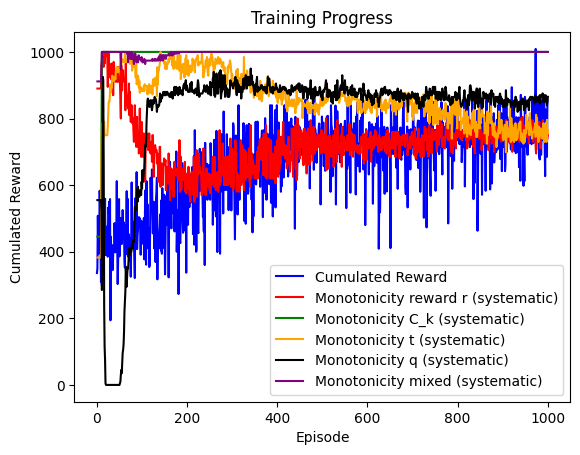

In [7]:
episodes = [x[0] for x in monotonicity_violations]
mono_c   = [x[1] * 1000 for x in monotonicity_violations]
mono_t   = [x[2] * 1000 for x in monotonicity_violations]
mono_r   = [x[3] * 1000 for x in monotonicity_violations]
mono_q   = [x[4] * 1000 for x in monotonicity_violations]
mono_mixed = [x[5] * 1000 for x in monotonicity_violations]

plt.plot(reward_history, color="blue", label="Cumulated Reward")
plt.plot(episodes, mono_r,  color="red",    label="Monotonicity reward r (systematic)")
plt.plot(episodes, mono_c, color="green",  label="Monotonicity C_k (systematic)")
plt.plot(episodes, mono_t, color="orange", label="Monotonicity t (systematic)")
plt.plot(episodes, mono_q, color="black",   label="Monotonicity q (systematic)")
plt.plot(episodes, mono_mixed, color="purple", label="Monotonicity mixed (systematic)")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()